# 1 - Dask Cluster

256 GB compute node, 235 GB Dask Memory with 2 workers 118 GB each.

In [1]:
import dask
from distributed import Client, LocalCluster
dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})
cluster = LocalCluster(n_workers=2, threads_per_worker=1)
client = Client(cluster)

client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/a270223/levante-spawner-preset//proxy/8787/status,
Dashboard: /user/a270223/levante-spawner-preset//proxy/8787/status,Workers: 2
Total threads: 2,Total memory: 235.37 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34289,Workers: 2
Dashboard: /user/a270223/levante-spawner-preset//proxy/8787/status,Total threads: 2
Started: Just now,Total memory: 235.37 GiB
Comm: tcp://127.0.0.1:42447,Total threads: 1
Dashboard: /user/a270223/levante-spawner-preset//proxy/32769/status,Memory: 117.68 GiB
Nanny: tcp://127.0.0.1:33781,


In [2]:
from dask.utils import ensure_dict, format_bytes
workers = client.scheduler_info()["workers"]
text="Workers= " + str(len(workers))
memory = [w["memory_limit"] for w in workers.values()]
if all(memory):
    text += ", Memory=" + format_bytes(sum(memory))
print(text)

Workers= 2, Memory=235.37 GiB


# 2 - Data access

In [3]:
%%time
import xarray as xr
import matplotlib.pylab as plt
import numpy as np

from aqua import Reader, catalogue
# catalogue(configdir='/home/a/a270223/AQUA/config')
catalogue(configdir='/work/ab0995/a270223/AQUA/config')
# path = '/home/a/a270223/AQUA/config/levante/catalog.yaml'
path = '/work/ab0995/a270223/AQUA/config/levante/catalog.yaml'

CPU times: user 1.91 s, sys: 459 ms, total: 2.37 s
Wall time: 4.78 s


AQUA reader for fesom

In [4]:
%%time
reader = Reader(model="FESOM", exp="tco2559-ng5", source="original_2d", regrid="r005")
fesom_cat = reader.retrieve(fix=False)
fesom_cat

CPU times: user 4.58 s, sys: 2.41 s, total: 7 s
Wall time: 50.8 s


<xarray.Dataset>
Dimensions:   (time: 8328, nod2: 7402886)
Coordinates:
  * time      (time) datetime64[ns] 2020-01-20T00:56:00 ... 2020-12-31T23:56:00
Dimensions without coordinates: nod2
Data variables: (12/19)
    MLD1      (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    MLD2      (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    a_ice     (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    atmice_x  (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    atmice_y  (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    atmoce_x  (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    ...        ...
    ssh       (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    sss       (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    sst       (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    uice      (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    vice      (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    vve_5     (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
Attributes: (12/17)
    FESOM_model:                         FESOM2
    FESOM_website:                       fesom.de
    FESOM_git_SHA:                       469e74b1
    FESOM_MeshPath:                      /ec/res4/scratch/natr/RAPS/20/inputs...
    FESOM_mesh_representative_checksum:  
    FESOM_ClimateDataPath:               /ec/res4/scratch/natr/RAPS/20/inputs...
    ...                                  ...
    FESOM_use_floatice:                  0
    FESOM_whichEVP:                      1
    FESOM_evp_rheol_steps:               120
    FESOM_opt_visc:                      5
    FESOM_use_wsplit:                    -1
    history:                             2023-04-25 09:36:02 retrieved by AQU...

# 3 - fesom sea surface height

In [5]:
fesom_ssh = fesom_cat['ssh']
fesom_ssh

<xarray.DataArray 'ssh' (time: 8328, nod2: 7402886)>
dask.array<concatenate, shape=(8328, 7402886), dtype=float32, chunksize=(1, 7402886), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2020-01-20T00:56:00 ... 2020-12-31T23:56:00
Dimensions without coordinates: nod2
Attributes:
    description:  sea surface elevation
    long_name:    sea surface elevation
    units:        m

Compute and persist are both ways to materialize results in memory. Compute materializes results in a pandas DataFrame and Dask persist materializes the results in a Dask DataFrame. Compute only works for tiny datasets that fit in the memory of a single machine. This is why persist is better as it works for larger than memory datasets.

In [7]:
fesom_ssh_std = fesom_ssh.std(axis=0).persist()
fesom_ssh_std

<xarray.DataArray 'ssh' (nod2: 7402886)>
dask.array<_sqrt, shape=(7402886,), dtype=float32, chunksize=(7402886,), chunktype=numpy.ndarray>
Dimensions without coordinates: nod2

CPU times: user 3min 14s, sys: 14.9 s, total: 3min 29s
Wall time: 50min 55s


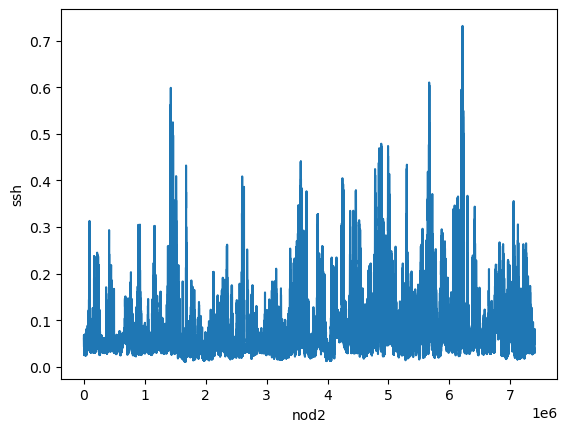

In [8]:
%%time
fesom_ssh_std.plot()

# 4 - regridding and visualization

regridder

In [9]:
%%time
fesom_ssh_std_regrid = reader.regrid(fesom_ssh_std)
fesom_ssh_std_regrid

CPU times: user 472 ms, sys: 44.3 ms, total: 517 ms
Wall time: 6.03 s


<xarray.DataArray 'ssh' (lat: 3600, lon: 7200)>
dask.array<reshape, shape=(3600, 7200), dtype=float64, chunksize=(3600, 7200), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -89.97 -89.92 -89.88 -89.83 ... 89.88 89.92 89.97
  * lon      (lon) float64 0.0 0.05 0.1 0.15 0.2 ... 359.8 359.9 359.9 359.9
Attributes:
    regridded:  1
    history:    2023-04-25 10:44:49 regridded by AQUA fixer;\n

visualization 1

CPU times: user 3.83 s, sys: 647 ms, total: 4.47 s
Wall time: 16.6 s


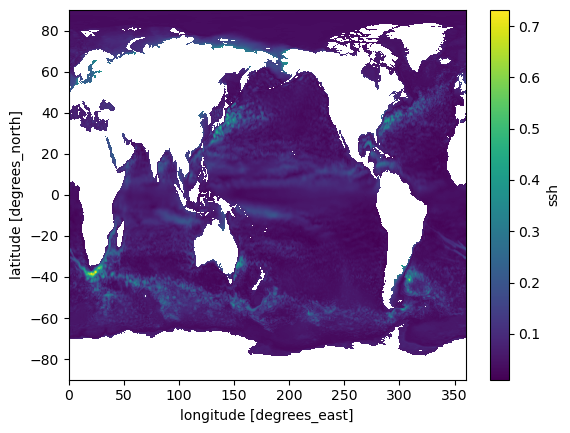

In [12]:
%%time
fesom_ssh_std_regrid.plot()

visualization 2

CPU times: user 3.91 s, sys: 656 ms, total: 4.57 s
Wall time: 17.2 s


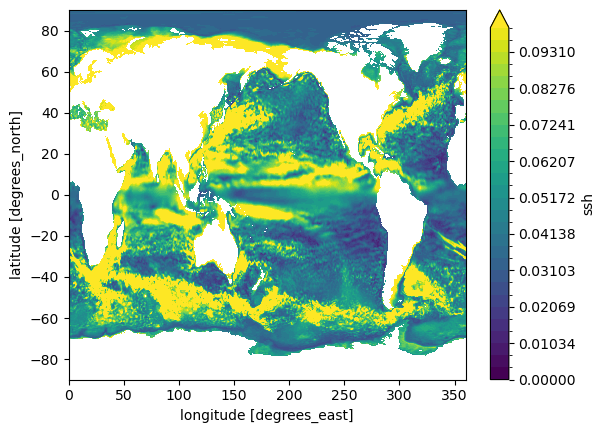

In [13]:
%%time
fesom_ssh_std_regrid.plot(levels = np.linspace(0, 0.1, 30))